In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D


df = pd.read_csv('ImpactoAI.csv')
 
CORES = ['#1e6b7a', '#e8a020', '#1a3a5c', '#4a9aba', '#c0392b']

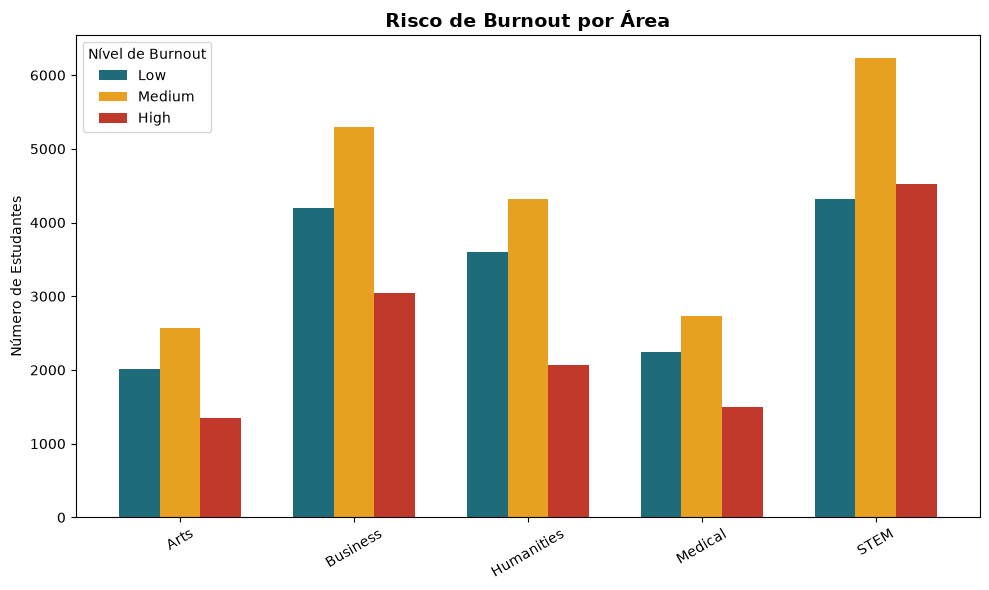

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
 
burnout = df.groupby(['Major_Category', 'Burnout_Risk_Level']).size().unstack()
burnout = burnout[['Low', 'Medium', 'High']]
burnout.plot(kind='bar', ax=ax, color=['#1e6b7a', '#e8a020', '#c0392b'], width=0.7)
 
ax.set_title('Risco de Burnout por Área', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Número de Estudantes')
ax.legend(title='Nível de Burnout')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

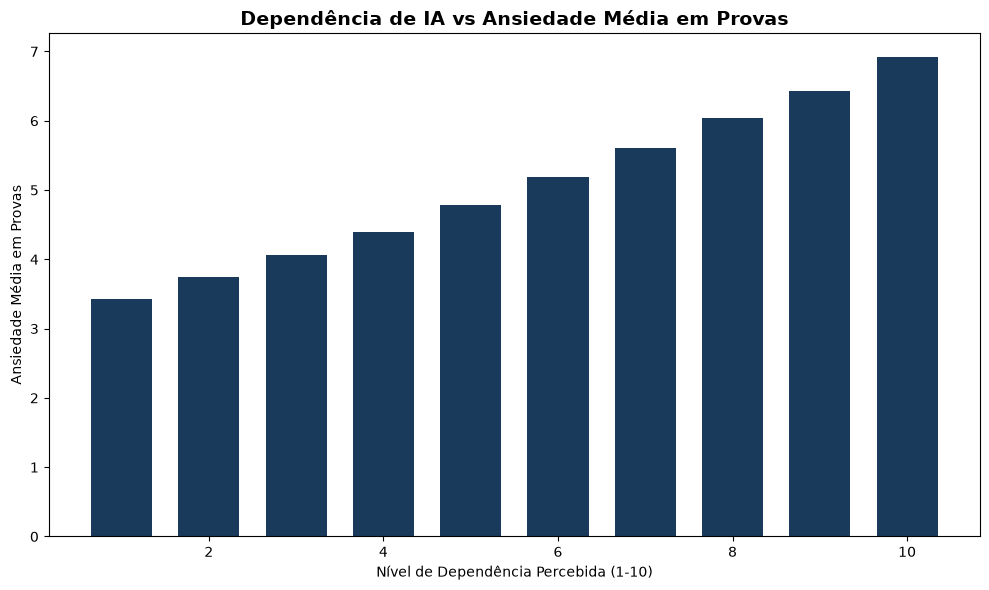

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
 
media = df.groupby('Perceived_AI_Dependency')['Anxiety_Level_During_Exams'].mean()
ax.bar(media.index, media.values, color='#1a3a5c', width=0.7)
 
ax.set_title('Dependência de IA vs Ansiedade Média em Provas', fontsize=14, fontweight='bold')
ax.set_xlabel('Nível de Dependência Percebida (1-10)')
ax.set_ylabel('Ansiedade Média em Provas')
plt.tight_layout()

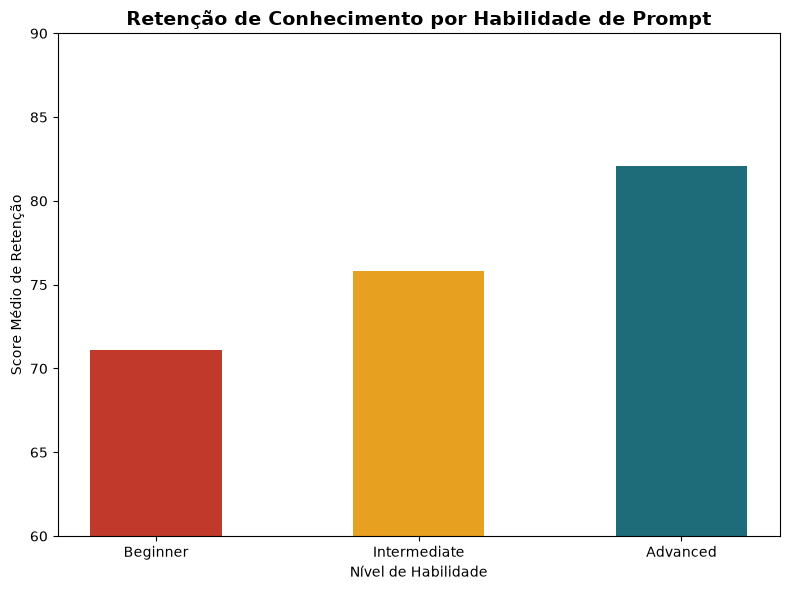

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
 
ordem = ['Beginner', 'Intermediate', 'Advanced']
media_ret = df.groupby('Prompt_Engineering_Skill')['Skill_Retention_Score'].mean().reindex(ordem)
ax.bar(media_ret.index, media_ret.values, color=['#c0392b', '#e8a020', '#1e6b7a'], width=0.5)
 
ax.set_title('Retenção de Conhecimento por Habilidade de Prompt', fontsize=14, fontweight='bold')
ax.set_xlabel('Nível de Habilidade')
ax.set_ylabel('Score Médio de Retenção')
ax.set_ylim(60, 90)
plt.tight_layout()

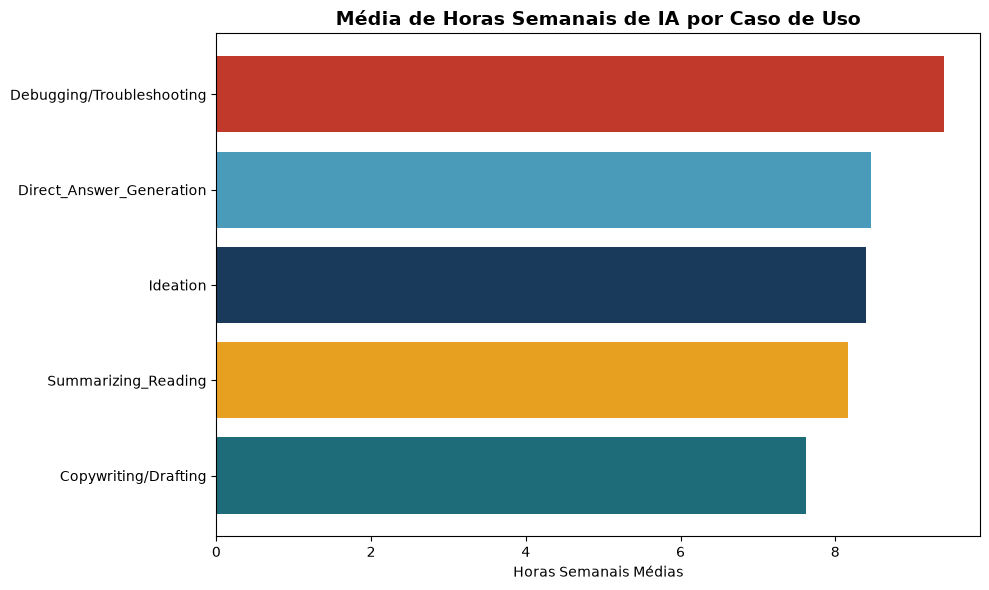

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
 
media_uso = df.groupby('Primary_Use_Case')['Weekly_GenAI_Hours'].mean().sort_values()
ax.barh(media_uso.index, media_uso.values, color=CORES)
 
ax.set_title('Média de Horas Semanais de IA por Caso de Uso', fontsize=14, fontweight='bold')
ax.set_xlabel('Horas Semanais Médias')
plt.tight_layout()

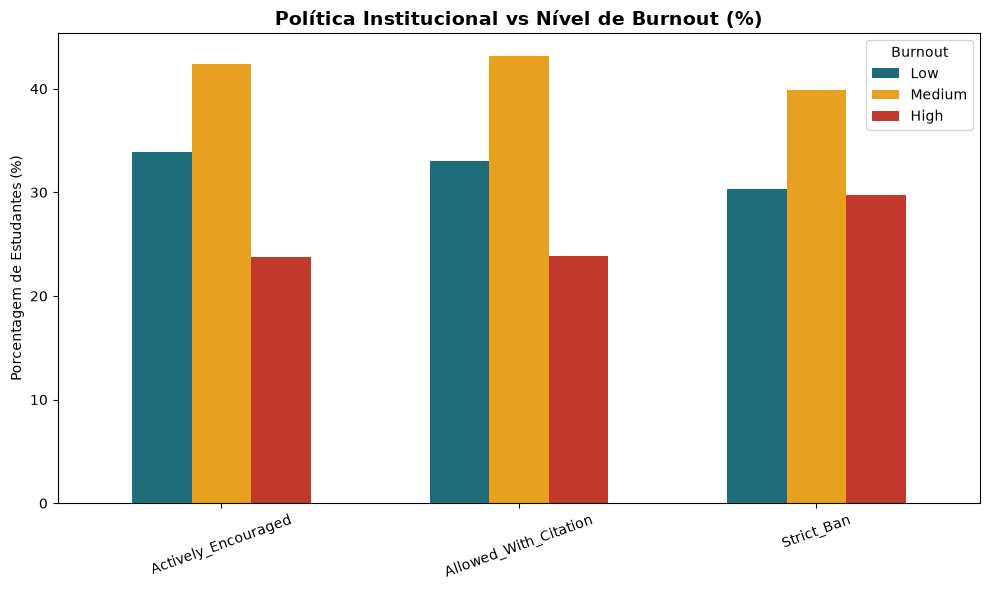

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
 
politica = df.groupby(['Institutional_Policy', 'Burnout_Risk_Level']).size().unstack()
politica_pct = politica.div(politica.sum(axis=1), axis=0) * 100
politica_pct = politica_pct[['Low', 'Medium', 'High']]
politica_pct.plot(kind='bar', ax=ax, color=['#1e6b7a', '#e8a020', '#c0392b'], width=0.6)
 
ax.set_title('Política Institucional vs Nível de Burnout (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Porcentagem de Estudantes (%)')
ax.legend(title='Burnout')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()

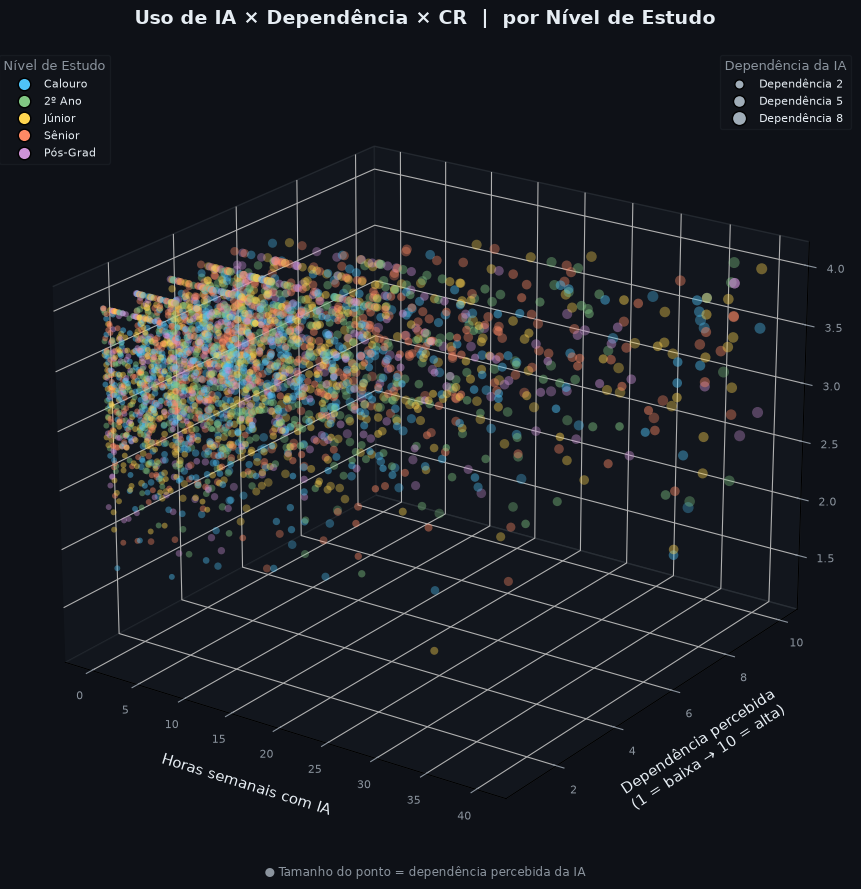

In [8]:
sample = df.sample(n=3000, random_state=42)

year_order  = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
year_labels = {'Freshman': 'Calouro', 'Sophomore': '2º Ano',
               'Junior': 'Júnior', 'Senior': 'Sênior', 'Graduate': 'Pós-Grad'}

palette = {
    'Freshman':  '#4FC3F7',   
    'Sophomore': '#81C784',   
    'Junior':    '#FFD54F',   
    'Senior':    '#FF8A65',   
    'Graduate':  '#CE93D8',  
}

colors  = sample['Year_of_Study'].map(palette)
sizes   = 18 + (sample['Perceived_AI_Dependency'] - 1) * 5   

fig = plt.figure(figsize=(13, 9), facecolor='#0E1117')
ax  = fig.add_subplot(111, projection='3d', facecolor='#0E1117')

sc = ax.scatter(
    sample['Weekly_GenAI_Hours'],
    sample['Perceived_AI_Dependency'],
    sample['Post_Semester_GPA'],
    c=colors,
    s=sizes,
    alpha=0.72,
    edgecolors='none',
    depthshade=True,
)

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill       = True
    pane.set_facecolor('#161B22')
    pane.set_alpha(0.6)
    pane.set_edgecolor('#30363D')

ax.grid(True, color='#30363D', linewidth=0.5, linestyle='--')

kw = dict(color='#E6EDF3', fontsize=11, labelpad=10)
ax.set_xlabel('Horas semanais com IA',   **kw)
ax.set_ylabel('Dependência percebida\n(1 = baixa → 10 = alta)', **kw)
ax.set_zlabel('CR pós-semestre (GPA)',   **kw)

ax.tick_params(colors='#8B949E', labelsize=8)
for spine in ax.spines.values():
    spine.set_color('#30363D')

ax.set_title(
    'Uso de IA × Dependência × CR  |  por Nível de Estudo',
    color='#E6EDF3', fontsize=14, fontweight='bold', pad=18
)

legend_year = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=palette[y], markersize=9,
           label=year_labels[y])
    for y in year_order
]

dep_levels = [2, 5, 8]
legend_dep = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='#A0ADB8',
           markersize=np.sqrt(18 + (d - 1) * 5) * 1.4,
           label=f'Dependência {d}')
    for d in dep_levels
]

leg1 = ax.legend(handles=legend_year, title='Nível de Estudo',
                 loc='upper left', bbox_to_anchor=(-0.02, 1.0),
                 framealpha=0.25, facecolor='#161B22',
                 labelcolor='#E6EDF3', title_fontsize=9,
                 fontsize=8, edgecolor='#30363D')
leg1.get_title().set_color('#8B949E')

leg2 = ax.legend(handles=legend_dep, title='Dependência da IA',
                 loc='upper right', bbox_to_anchor=(1.02, 1.0),
                 framealpha=0.25, facecolor='#161B22',
                 labelcolor='#E6EDF3', title_fontsize=9,
                 fontsize=8, edgecolor='#30363D')
leg2.get_title().set_color('#8B949E')

ax.add_artist(leg1)  

fig.text(0.50, 0.02,
         '● Tamanho do ponto = dependência percebida da IA',
         ha='center', color='#8B949E', fontsize=8.5)

ax.view_init(elev=22, azim=-55)

plt.tight_layout()